<a href="https://colab.research.google.com/github/Angelorigo/MODELOS-ESTOCASTICOS/blob/main/INSTRUCTIVO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Instructivo: SymPy y NetworkX

**SymPy**

Esta es una librería para matemática simbólica, i.e., que *puede hacer matemáticas usando símbolos explícitos*, en vez de sólo darte un resultado de regreso (Como si lo estuvieras haciendo a mano).


Principalmente sirve para resolver ecuaciones algebráicas, calcular derivadas, integrales, simplificar expresiones y trabajar con matrices; Esta última función es la que más vamos a estar usando en este curso, ya que nos va a evitar hacer el cálculo a mano de las mismas.


Para usarla, es necesario primero importar la librería en el preámbulo de tu programa:

In [1]:
import sympy as sp

Ahora, definimos nuestra matriz del tamaño deseado de la siguiente manera:

In [2]:
M = sp.Matrix([ [1, 2, 3], [5, 7, 9], [11, 13, 17] ])

O de la siguiente manera para una mejor visualización:

In [ ]:
M = sp.Matrix([
    [1, 2, 3],
    [5, 7, 9],
    [11, 13, 17],
])

Teniendo la matriz, podemos hacer varias cosas:


- Extraer valores específicos: M[fila, columna]


In [3]:
# Por ejemplo, si queremos extraer el NÚMERO 7, hacemos lo siguiente:
valor = M[1, 1]
# Recuerda que la numeración empieza en 0.

- Extraer toda una fila: M.row(índice)

In [4]:
# Por ejemplo, si queremos extraer la FILA 2, hacemos lo siguiente:
fila = M.row(1)
# Ten en cuenta que la numeración empieza en 0.

- Extraer toda una columna: M.col(índice)

In [5]:
# Por ejemplo, si queremos extraer la COLUMNA 2, hacemos lo siguiente:
columna = M.col(1)
# De igual manera, la numeración empieza en 0.

Para verificar que los datos extraidos sean los correctos, usamos print(valor extraido).

En este ejemplo obtuvimos los vectores con el valor 7 en ellos.

In [6]:
print(valor)
print(fila)
print(columna)

7
Matrix([[5, 7, 9]])
Matrix([[2], [7], [13]])


**NetworkX**

Esta es una herramienta muy útil a la hora de crear, manipular y visualizar grafos (o redes), i.e., una colección de nodos conectados por aristas, los cuales pueden ser dirigidos o no dirigidos.

Sus principales aplicaciones son:
- para analizar comportamientos, como redes sociales (por las listas de amigos)
- Rutas logísticas (encontrar caminos más cortos).

 Y ya yéndonos a lo extremo,
 - para modelar la propagación de un virus.

Para usarla, es necesario primero importar la librería en el preámbulo de tu programa:

In [14]:
import networkx as nx
#  No olvidemos el matplot para graficar, se usará más tarde
import matplotlib.pyplot as plt

Posteriormente, definimos un grafo G vacío, el cual en este caso, un solo nodo puede tener más de una unión:

In [15]:
G = nx.MultiGraph()

Ahora, vamos construyéndolo poco a poco, de acuerdo al propósito del mismo.
En este caso vamos a representar las amistades en un entorno de trabajo.

G.add_edge('NOMBRE', 'NOMBRE')

In [16]:
G.add_edge('David', 'Angel')
G.add_edge('Angel', 'Daniela')
G.add_edge('Daniela', 'David')
G.add_edge('Angel', 'Liz')
G.add_edge('Liz', 'Berna')
G.add_edge('Berna', 'Gael')
G.add_edge('Gael', 'Daniela')
G.add_edge('Clau', 'Liz')
G.add_edge('Rodrigo', 'Angel')
G.add_edge('Rodrigo', 'Liz')

0

En este contexto, podemos saber cuántos amigos tiene cada quién, o sea, cuántas conexiones tiene cada nodo:

In [17]:
print(f"Ángel tiene {G.degree['Angel']} amigos en el trabajo")

Ángel tiene 4 amigos en el trabajo


Además, si la información sobre algún trabajo tuviera que pasar entre los trabajadores urgentemente, podemos obtener el número mínimo de personas que cada quién tiene para la tarea, o sea, el numero mínimo de saltos entre cada nodo:

In [18]:
saltos = nx.shortest_path_length(G, source = 'Gael', target = 'Clau')
print(f"Gael necesita {saltos} amigos para pasar la información rápido a Clau")

Gael necesita 3 amigos para pasar la información rápido a Clau


Ahora, si el jefe pregunta quienes pasaron la información, también podemos obtener la lista, i.e., el path recorrido:

In [19]:
camino = nx.shortest_path(G, source = 'Gael', target = 'Clau')
print(f"La información pasó por: {camino} ")

La información pasó por: ['Gael', 'Berna', 'Liz', 'Clau'] 


Finalmente, pero no menos importante, observemos este mismo path, de manera gráfica

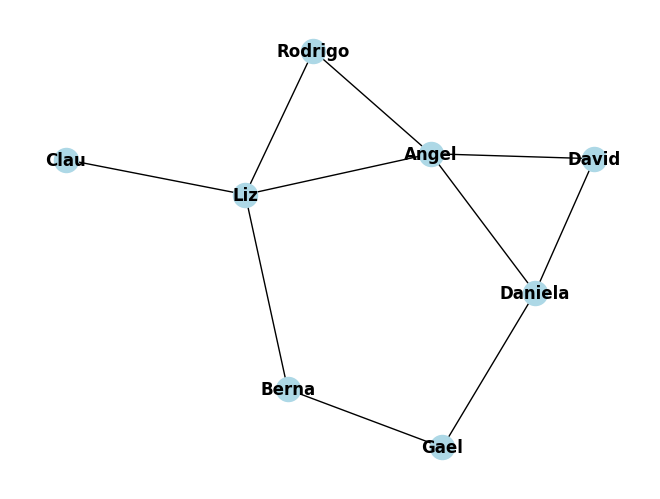

In [20]:
nx.draw(G, with_labels=True, node_color='lightblue', font_weight='bold')
plt.show()